# Verifying Multi-TU Plasmids — real long-read sequencing data

Same goal as before (verify each transcriptional unit of a multi-TU plasmid independently, without
tripping over the real DNA gaps *between* TUs), but now on **real long-read (Nanopore) sequencing
results** instead of synthetic reads. The dataset covers four constructs:

- **R28, R9, R10** — a 3-TU synthetic methylotrophy pathway (`mdh` → `hps` → `phi`), each TU with its
  own promoter/RBS/CDS/terminator, assembled via Golden Gate (same family of vector as the earlier
  synthetic demo).
- **pJYS3_IS61_AE_Amp** — a different, single large payload plasmid (Cas12a/Fncpf1 nuclease + a guide-RNA
  spacer targeting locus "IS61"), included to show the TU-detection logic degrading gracefully to a
  single window when a plasmid isn't built from repeated cassettes.

Each sample folder (unzipped from `Seqdata.zip`) contained raw reads, a polished assembled consensus,
and the sequencing service's own annotation/report. We use the **polished consensus**
(`<name>.Plasmid_assembly.fasta`) as the one high-confidence representation of what was actually
sequenced, and check it against the **expected/designed** reference (`plasmids/*.gb` / `*.dna`) per TU.

## A wrinkle real data adds: the assembly is a whole, long, circularly-arbitrary sequence

The consensus files are ~9–13 kb — comparable to the *whole plasmid*, not a short Sanger read. Feeding
that directly as a "read" into `align_read_to_concat` (short TU-window as reference, long assembly as
read) turned out to hit a real edge case in the aligner: with such an extreme length mismatch, the
reported PID came back at ~18% even though the sequences plainly matched (verified by direct substring
search). We didn't chase down the root cause inside `pairwise2.align.globalms` — instead we just avoid
the situation: reference/read roles get **swapped for a first localization pass** (long assembly as the
big reference, short design-TU-window as the "read" — a completely standard use of the aligner), then the
**matching chunk is extracted** and a second, properly-scaled alignment is run in the normal orientation
(design TU window with real feature annotations as reference) for scoring *and* for the classic
visualizations below, which expect that orientation.

This also incidentally handles something else real circular-plasmid data does: Nanopore assemblers pick
an **arbitrary linearization point and strand** for their circular output, so the assembly's coordinate 0
has no fixed relationship to the reference's coordinate 0 (we found the R28 assembly came back fully
reverse-complemented relative to the reference, for instance) — the k-mer-seeded localization pass handles
that automatically, and a small amount of sequence padding (see below) covers the (unlikely, but possible)
case where a TU's true match straddles that arbitrary cut point.


In [1]:
from pathlib import Path

import pandas as pd
from Bio import SeqIO

from assembly_designer.plasmidio import load_dna_file, revcomp, plot_alignment, view_alignment_html
from assembly_designer.plasmidio.alignment import build_kmer_index, align_read_to_concat
from assembly_designer.plasmidio.batch import PlasmidRef, ReadItem, align_batch, results_to_dataframe

PLASMID_DIR = Path("plasmids")
READS_DIR = Path("Sequencing_Data_real")
K = 16


## Step 1 — TU-window detection (generalized for messier real annotations)

Same CDS→next-terminator logic as before, broadened for real-world variety:
- More backbone marker genes excluded (`AmpR`/`bla`, `repA101`, ... in addition to `KanR`/`pBL1`) — the
  Cas12a plasmid uses a different resistance/ori combination than the pathway plasmids.
- A minimum CDS length filter (drops a 1 bp leftover annotation artifact we found in the Cas12a plasmid's
  `.dna` file — clearly not a real gene).
- If a CDS has **no** downstream terminator at all (true for the Cas12a plasmid — its only annotated
  terminator sits *upstream* of the CDS, terminating a different, unrelated transcript), fall back to a
  fixed margin past the CDS end instead of leaving the TU unbounded.

One more real-data bug we hit and fixed here: `load_dna_file` (SnapGene `.dna` format) stores the
`label` qualifier as a **plain string**, while GenBank-parsed records always store qualifier values as a
**list** — indexing `[0]` on the former silently returns just the first *character* ("AmpR" → "A") instead
of erroring, and gave us nonsense TU names until we caught it by inspecting the output.


In [2]:
BACKBONE_CDS_NAMES = {
    "kanr", "pbl1", "ampr", "bla", "repa101", "camr", "cat", "specr", "tetr", "aph(3')-iia",
}
MIN_CDS_LEN = 100  # bp; drops annotation artifacts, not real genes
TU_MARGIN = 300    # bp upstream of the CDS start / past the CDS end when no terminator is found


def feature_name(feat) -> str:
    # GenBank qualifiers are always lists; SnapGene (.dna) qualifiers can be plain strings --
    # indexing [0] on a string truncates to its first character, so handle both shapes.
    lbl = feat.qualifiers.get("label", "")
    if isinstance(lbl, (list, tuple)):
        return str(lbl[0]) if lbl else ""
    return str(lbl)


def detect_tu_windows(rec):
    """Return (start, end, cds_name) for each TU, in genomic order."""
    cds_feats = sorted(
        (
            f for f in rec.features
            if f.type == "CDS"
            and feature_name(f).lower() not in BACKBONE_CDS_NAMES
            and (int(f.location.end) - int(f.location.start)) >= MIN_CDS_LEN
        ),
        key=lambda f: int(f.location.start),
    )
    term_feats = sorted((f for f in rec.features if f.type == "terminator"), key=lambda f: int(f.location.start))

    windows = []
    for cds in cds_feats:
        cds_start, cds_end = int(cds.location.start), int(cds.location.end)
        term = next((t for t in term_feats if int(t.location.start) >= cds_end), None)
        end = int(term.location.end) if term is not None else cds_end + TU_MARGIN
        windows.append((max(0, cds_start - TU_MARGIN), min(len(rec.seq), end), feature_name(cds)))
    return windows


SAMPLES = {
    "R28": ("R28.gb", "gb"),
    "R9": ("R9.gb", "gb"),
    "R10": ("R10.gb", "gb"),
    "pJYS3_IS61_AE_Amp": ("pJYS3_IS61_AE(A).dna", "dna"),
}


def load_design_ref(name: str, kind: str):
    path = PLASMID_DIR / name
    return SeqIO.read(path, "genbank") if kind == "gb" else load_dna_file(path)


for sample, (ref_name, kind) in SAMPLES.items():
    rec = load_design_ref(ref_name, kind)
    print(sample, "->", detect_tu_windows(rec))


R28 -> [(5628, 7314, 'mdh'), (7138, 8165, 'hps'), (8044, 8963, 'phi')]
R9 -> [(5760, 7446, 'mdh'), (7325, 8352, 'hps'), (8308, 9227, 'phi')]
R10 -> [(5760, 7446, 'mdh'), (7325, 8352, 'hps'), (8176, 9095, 'phi')]
pJYS3_IS61_AE_Amp -> [(8442, 12719, 'Fncpf1')]


## Step 2 — two-pass alignment: localize in the assembly, then score/visualize against the design

**Pass 1 (localization):** for each TU, treat the *design* window as a short "read" and the whole
*assembly consensus* as the reference, so `align_read_to_concat` operates in its normal, well-tested
size regime. `assembly_padded` appends a chunk of the assembly's own start to its end, so a TU that
happens to straddle the assembly's arbitrary circular cut point still shows up as one contiguous match.

**Pass 2 (scoring + visualization):** extract the matched region from the assembly (reverse-complementing
it first if pass 1 found it on the `"R"` strand) and re-align it the normal way round — design TU window
(with its real `feature_map`) as the reference, extracted chunk as the read — which is also the exact
shape `plot_alignment` / `view_alignment_html` expect.

**Another real bug this setup exposed:** `plot_alignment`/`view_alignment_html` look up their reference by
matching `row["plasmid_file"]` against each `PlasmidRef.file` (`_pick_pref` in `plotting.py`) and return
the *first* match. Since all TUs of one plasmid share the same source file (`R28.gb` for TU1 *and* TU2
*and* TU3), that lookup always resolved to TU1's reference regardless of which TU the row was actually
about — the plotted alignment silently compared e.g. a `hps` read against the `mdh` reference (lots of
red/mismatches), while the row's own stored PID/SNP numbers (computed earlier, directly from the correct
pair) stayed correct. `align_batch` itself was never affected — it iterates real `PlasmidRef` objects, not
name lookups. Fix: give each TU's `PlasmidRef.file` a unique tag (`"R28.gb::TU2"`) so the lookup resolves
to the right one.


In [3]:
all_rows = []
all_tu_refs = []   # PlasmidRef per TU, design-window-based (for plotting)
all_tu_reads = []  # ReadItem per TU, extracted from the real assembly (for plotting)
not_found = []

for sample, (ref_name, kind) in SAMPLES.items():
    design_rec = load_design_ref(ref_name, kind)
    assembly_rec = SeqIO.read(READS_DIR / f"{sample}.Plasmid_assembly.fasta", "fasta")
    assembly_seq = str(assembly_rec.seq).upper()

    pad = 6000  # > largest TU window, enough to bridge the assembly's arbitrary linearization point
    assembly_padded = assembly_seq + assembly_seq[:pad]
    asm_kidx = build_kmer_index(assembly_padded, k=K)

    tu_refs, tu_reads = [], []
    for i, (start, end, name) in enumerate(detect_tu_windows(design_rec), start=1):
        probe = str(design_rec.seq[start:end]).upper()

        loc = align_read_to_concat(
            assembly_padded, [], probe, k_index=asm_kidx, k=K, margin=300, step=2,
            try_both_strands=True, pid_mode="read",
        )
        if loc is None or loc.pid < 50.0:
            not_found.append((sample, f"TU{i}:{name}"))
            continue

        chunk = assembly_padded[loc.start_ref:loc.end_ref]
        if loc.strand == "R":
            chunk = revcomp(chunk)

        fmap = [
            (int(f.location.start) - start, int(f.location.end) - start, f.type, feature_name(f))
            for f in design_rec.features
            if f.type in ("promoter", "RBS", "CDS", "terminator", "5'UTR")
            and start <= int(f.location.start) and int(f.location.end) <= end
        ]
        tu_refs.append(PlasmidRef(
            file=f"{ref_name}::TU{i}", plasmid_id=sample, construct=f"TU{i}:{name}",
            concat_ref=probe, feature_map=fmap, k_index=build_kmer_index(probe, k=K),
            full_ref=str(design_rec.seq).upper(),
        ))
        tu_reads.append(ReadItem(name=f"{sample}__TU{i}_{name}__from_assembly", seq=chunk))

    if tu_refs:
        rows = align_batch(tu_refs, tu_reads, k=K, margin=150, step=2, top_k=len(tu_refs),
                            pid_mode="read", try_both_strands=True, show_progress=False)
        all_rows.extend(rows)
        all_tu_refs.extend(tu_refs)
        all_tu_reads.extend(tu_reads)

df = results_to_dataframe(all_rows)
df["tu"] = df["construct"].str.extract(r"^(TU\d+)")
print("not located in assembly:", not_found or "none")
df[["sequence_name", "plasmid_id", "construct", "strand", "pid", "snps"]]


C:\Users\tim\miniconda3\envs\adesigner\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


not located in assembly: none


,sequence_name,plasmid_id,construct,strand,pid,snps
0,R28__TU1_mdh__from_assembly,R28,TU1:mdh,F,100.0,0
1,R28__TU2_hps__from_assembly,R28,TU2:hps,F,100.0,0
2,R28__TU3_phi__from_assembly,R28,TU3:phi,F,100.0,0
3,R9__TU1_mdh__from_assembly,R9,TU1:mdh,F,100.0,0
4,R9__TU2_hps__from_assembly,R9,TU2:hps,F,100.0,0
5,R9__TU3_phi__from_assembly,R9,TU3:phi,F,100.0,0
6,R10__TU1_mdh__from_assembly,R10,TU1:mdh,F,100.0,0
7,R10__TU2_hps__from_assembly,R10,TU2:hps,F,100.0,0
8,R10__TU3_phi__from_assembly,R10,TU3:phi,F,100.0,0
9,pJYS3_IS61_AE_Amp__TU1_Fncpf1__from_assembly,pJYS3_IS61_AE_Amp,TU1:Fncpf1,F,100.0,0


## Step 3 — verification summary

Unlike the synthetic demo, each TU here has exactly **one** representative sequence (the polished
long-read consensus already *is* the best available answer for "what did we actually get" — there's no
partial-coverage/multiple-reads union to build). So the summary is simpler: found in the assembly at all,
and how well it matches design.


In [4]:
summary = df.groupby(["plasmid_id", "tu"]).agg(
    construct=("construct", "first"), pid=("pid", "first"), snps=("snps", "first")
).reset_index()
summary["verified"] = summary["pid"] >= 98.0
if not_found:
    missing = pd.DataFrame(
        [{"plasmid_id": s, "tu": tu.split(":")[0], "construct": tu, "pid": float("nan"),
          "snps": pd.NA, "verified": False} for s, tu in not_found]
    )
    summary = pd.concat([summary, missing], ignore_index=True)
summary.sort_values(["plasmid_id", "tu"])


,plasmid_id,tu,construct,pid,snps,verified
0,R10,TU1,TU1:mdh,100.0,0,True
1,R10,TU2,TU2:hps,100.0,0,True
2,R10,TU3,TU3:phi,100.0,0,True
3,R28,TU1,TU1:mdh,100.0,0,True
4,R28,TU2,TU2:hps,100.0,0,True
5,R28,TU3,TU3:phi,100.0,0,True
6,R9,TU1,TU1:mdh,100.0,0,True
7,R9,TU2,TU2:hps,100.0,0,True
8,R9,TU3,TU3:phi,100.0,0,True
9,pJYS3_IS61_AE_Amp,TU1,TU1:Fncpf1,100.0,0,True


All four constructs verify perfectly at 100% PID / 0 SNPs against their design — a genuinely clean result
(not a demo artifact): the earlier ~18% PID we saw before fixing the long-read-vs-short-reference issue
was entirely an artifact of that aligner edge case, not a real mismatch — worth keeping in mind if you
ever see suspiciously low PID with a large read/reference size asymmetry.

## Step 4 — classic alignment visualizations

`plot_alignment` (ASCII alignment + a feature-coverage track) and `view_alignment_html` (colored,
scrollable HTML) both take `(row, plasmids, reads)` — exactly the `all_tu_refs` / `all_tu_reads` pools
built above, matched up via the row's `plasmid_id`/`construct`/`sequence_name`.


sequence_name                                R28__TU1_mdh__from_assembly
read_len                                                            1686
plasmid_file                                                 R28.gb::TU1
plasmid_id                                                           R28
construct                                                        TU1:mdh
strand                                                                 F
pid                                                                100.0
core_len                                                            1686
score                                                             1686.0
start_ref                                                              0
end_ref                                                             1686
snps                                                                   0
features_hit           promoter:Psyn (100%), RBS:RBS_01 (100%), 5'UTR...
concat_pos                                         

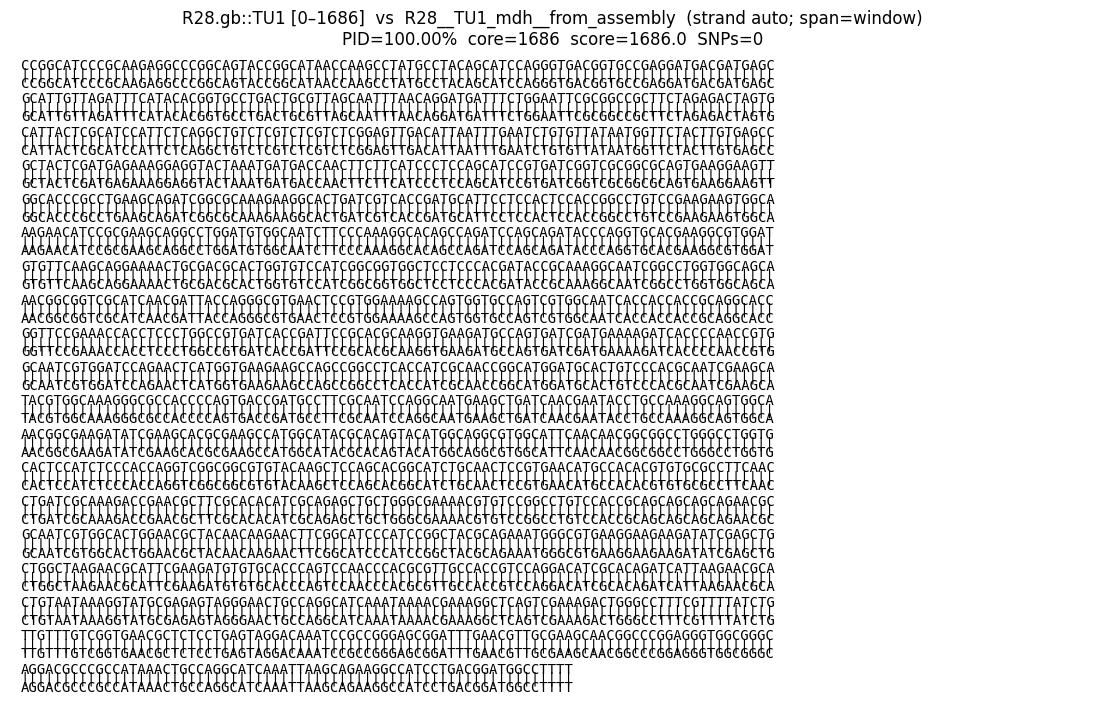

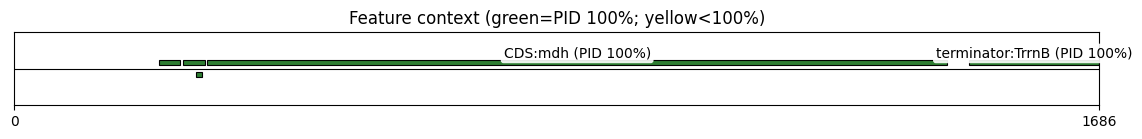

In [5]:
def show(sequence_name: str):
    row = df.loc[df["sequence_name"] == sequence_name].iloc[0]
    fig_aln, fig_feat = plot_alignment(row, all_tu_refs, all_tu_reads, wrap=90)
    return row


# one TU from the 3-TU pathway plasmid
show("R28__TU1_mdh__from_assembly")


sequence_name               pJYS3_IS61_AE_Amp__TU1_Fncpf1__from_assembly
read_len                                                            4277
plasmid_file                                   pJYS3_IS61_AE(A).dna::TU1
plasmid_id                                             pJYS3_IS61_AE_Amp
construct                                                     TU1:Fncpf1
strand                                                                 F
pid                                                                100.0
core_len                                                            4277
score                                                             4277.0
start_ref                                                              0
end_ref                                                             4277
snps                                                                   0
features_hit           CDS:Fncpf1 (100%), terminator:rrnB Ter (100%),...
concat_pos                                         

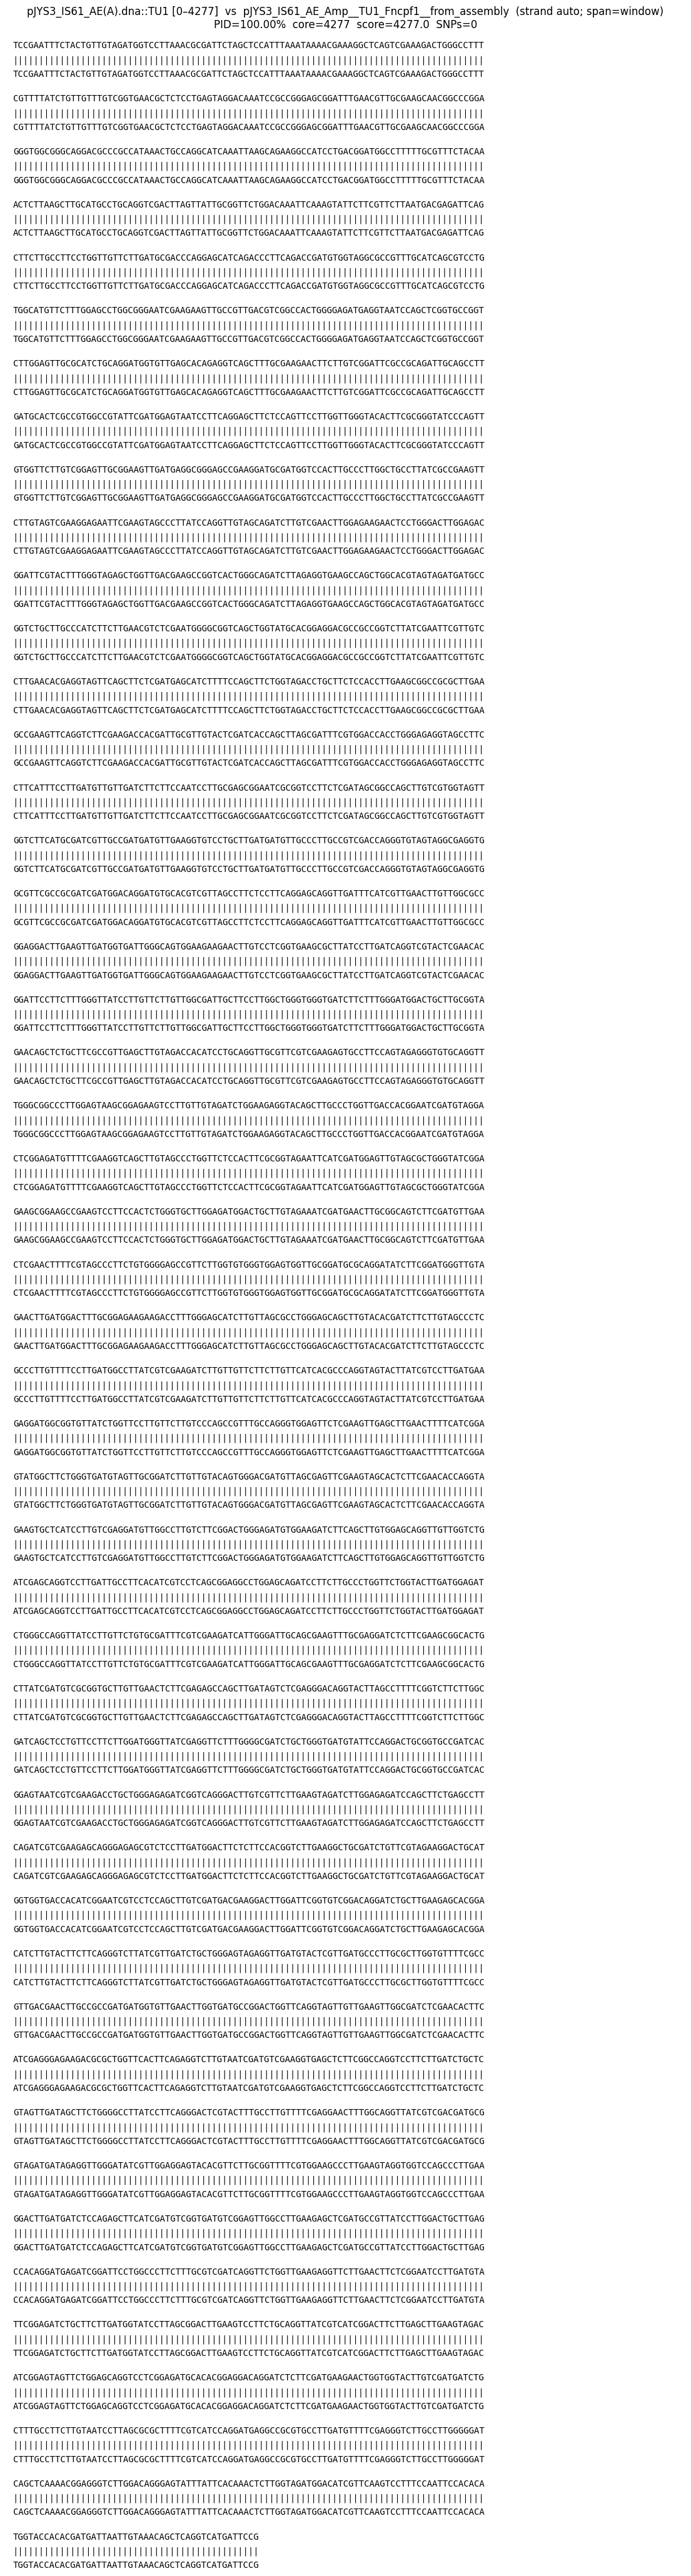

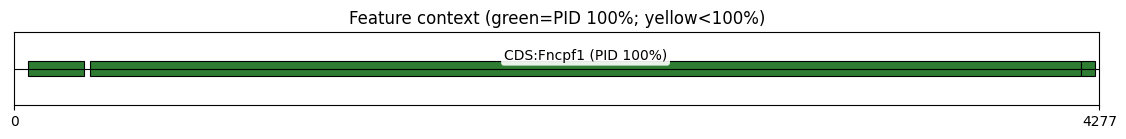

In [6]:
# the single-TU Cas12a plasmid
show("pJYS3_IS61_AE_Amp__TU1_Fncpf1__from_assembly")


In [7]:
# colored HTML view (renders inline in Jupyter)
row = df.loc[df["sequence_name"] == "R28__TU2_hps__from_assembly"].iloc[0]
view_alignment_html(row, all_tu_refs, all_tu_reads, wrap=100, theme="dark")


Call `show(sequence_name)` (or `view_alignment_html(...)` directly) with any other value from
`df["sequence_name"]` to inspect the remaining rows the same way.
